In [16]:
!pip install scikit-learn pandas numpy joblib requests matplotlib seaborn

In [17]:
import os
import ast
import subprocess
import tempfile
import requests
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    RocCurveDisplay
)
from sklearn.preprocessing import StandardScaler

In [18]:
class CodeFeatureExtractor:
    def extract_features(self, code: str):
        try:
            tree = ast.parse(code)
        except:
            return self._default()

        return {
            "loc": len([l for l in code.split("\n") if l.strip()]),
            "num_functions": sum(isinstance(n, ast.FunctionDef) for n in ast.walk(tree)),
            "cyclomatic_complexity": self._complexity(tree),
            "nesting_depth": self._nesting(tree),
            "num_imports": sum(isinstance(n, (ast.Import, ast.ImportFrom)) for n in ast.walk(tree)),
            "num_classes": sum(isinstance(n, ast.ClassDef) for n in ast.walk(tree)),
            "avg_function_length": self._avg_func_len(tree, code)
        }

    def _complexity(self, tree):
        c = 1
        for n in ast.walk(tree):
            if isinstance(n, (ast.If, ast.For, ast.While, ast.Try)):
                c += 1
        return float(c)

    def _nesting(self, tree):
        max_depth = 0
        def walk(node, depth=0):
            nonlocal max_depth
            max_depth = max(max_depth, depth)
            for child in ast.iter_child_nodes(node):
                walk(child, depth + 1)
        walk(tree)
        return max_depth

    def _avg_func_len(self, tree, code):
        lines = code.split("\n")
        lengths = []
        for n in ast.walk(tree):
            if isinstance(n, ast.FunctionDef):
                start = n.lineno - 1
                end = getattr(n, "end_lineno", len(lines))
                lengths.append(end - start)
        return sum(lengths)/len(lengths) if lengths else 0.0

    def _default(self):
        return {
            "loc": 0, "num_functions": 0, "cyclomatic_complexity": 1.0,
            "nesting_depth": 0, "num_imports": 0,
            "num_classes": 0, "avg_function_length": 0.0
        }

In [19]:
def fetch_repos(n=20):
    url = "https://api.github.com/search/repositories"
    params = {"q": "language:python stars:>500", "per_page": n}

    headers = {
        "Authorization": "token MY_GITHUB_TOKEN"
    }

    res = requests.get(url, params=params, headers=headers)
    data = res.json()

    if "items" not in data:
        print("Error:", data)
        return []

    return [r["clone_url"] for r in data["items"]]

In [20]:
import random

def label(features):
    score = 0
    if features['cyclomatic_complexity'] > 12: score += 1
    if features['nesting_depth'] > 4: score += 1

    base = 1 if score >= 2 else 0

    # add noise
    if random.random() < 0.1:
        return 1 - base

    return base

In [21]:
extractor = CodeFeatureExtractor()

def process_repo(repo_url):
    data = []
    with tempfile.TemporaryDirectory() as d:
        try:
            subprocess.run(["git", "clone", "--depth", "1", repo_url, d],
                           stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

            files = []
            for root, _, fs in os.walk(d):
                for f in fs:
                    if f.endswith(".py"):
                        files.append(os.path.join(root, f))

            files = files[:20]  # LIMIT → prevents overfitting

            for f in files:
                try:
                    code = open(f, encoding="utf-8", errors="ignore").read()
                    if len(code) < 100:
                        continue

                    feats = extractor.extract_features(code)
                    feats["label"] = label(feats)
                    data.append(feats)
                except:
                    pass
        except:
            pass

    return data

In [22]:
repos = fetch_repos(20)

dataset = []
for r in repos:
    print("Processing:", r)
    dataset.extend(process_repo(r))

df = pd.DataFrame(dataset)
print("Dataset size:", len(df))
df.head()

Processing: https://github.com/public-apis/public-apis.git


<unknown>:27: SyntaxWarning: invalid escape sequence '\s'
<unknown>:28: SyntaxWarning: invalid escape sequence '\*'
<unknown>:29: SyntaxWarning: invalid escape sequence '\['


Processing: https://github.com/EbookFoundation/free-programming-books.git
Processing: https://github.com/donnemartin/system-design-primer.git
Processing: https://github.com/vinta/awesome-python.git
Processing: https://github.com/TheAlgorithms/Python.git
Processing: https://github.com/Significant-Gravitas/AutoGPT.git
Processing: https://github.com/AUTOMATIC1111/stable-diffusion-webui.git
Processing: https://github.com/huggingface/transformers.git
Processing: https://github.com/yt-dlp/yt-dlp.git
Processing: https://github.com/521xueweihan/HelloGitHub.git
Processing: https://github.com/langflow-ai/langflow.git
Processing: https://github.com/ytdl-org/youtube-dl.git
Processing: https://github.com/langchain-ai/langchain.git
Processing: https://github.com/open-webui/open-webui.git
Processing: https://github.com/anthropics/skills.git
Processing: https://github.com/microsoft/markitdown.git
Processing: https://github.com/Comfy-Org/ComfyUI.git
Processing: https://github.com/Shubhamsaboo/awesome-l

,loc,num_functions,cyclomatic_complexity,nesting_depth,num_imports,num_classes,avg_function_length,label
0,192,11,30.0,13,4,0,18.909091,1
1,188,11,24.0,10,6,0,20.090909,1
2,133,9,3.0,9,6,2,16.555556,0
3,363,24,13.0,10,11,1,17.708333,1
4,476,6,59.0,17,7,0,88.500000,1


In [23]:
FEATURES = [
    'loc','num_functions','cyclomatic_complexity',
    'nesting_depth','num_imports','num_classes',
    'avg_function_length'
]

X = df[FEATURES]
y = df["label"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.25, random_state=42, stratify=y
)

In [24]:
# Logistic Regression
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

# Random Forest (regularized)
rf_model = RandomForestClassifier(
    n_estimators=80,
    max_depth=8,              # PREVENT OVERFIT
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)
rf_model.fit(X_train, y_train)

RandomForestClassifier(max_depth=8, min_samples_leaf=5, min_samples_split=10,
                       n_estimators=80, random_state=42)

In [25]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

log_cv = cross_val_score(log_model, X_scaled, y, cv=cv, scoring='f1')
rf_cv = cross_val_score(rf_model, X_scaled, y, cv=cv, scoring='f1')

print("Logistic F1 CV:", log_cv.mean())
print("RandomForest F1 CV:", rf_cv.mean())

Logistic F1 CV: 0.5408001487455305
RandomForest F1 CV: 0.8443665754535319


In [26]:
def evaluate(model, name):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]

    print(f"\n{name} RESULTS")
    print(classification_report(y_test, y_pred))

    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1:", f1_score(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, y_prob))

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d")
    plt.title(f"{name} Confusion Matrix")
    plt.show()

    RocCurveDisplay.from_predictions(y_test, y_prob)
    plt.title(f"{name} ROC Curve")
    plt.show()


Logistic Regression RESULTS
              precision    recall  f1-score   support

           0       0.81      0.91      0.86        46
           1       0.82      0.64      0.72        28

    accuracy                           0.81        74
   macro avg       0.81      0.78      0.79        74
weighted avg       0.81      0.81      0.81        74

Accuracy: 0.8108108108108109
Precision: 0.8181818181818182
Recall: 0.6428571428571429
F1: 0.72
ROC-AUC: 0.8773291925465838


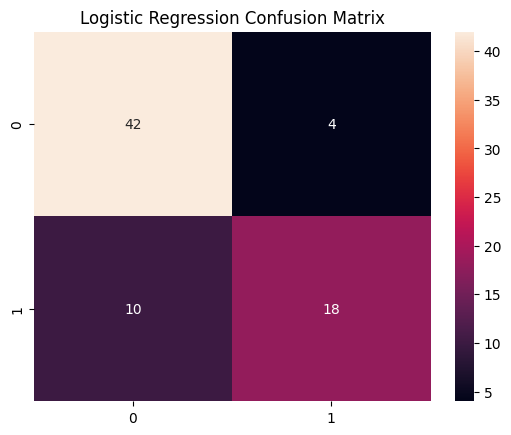

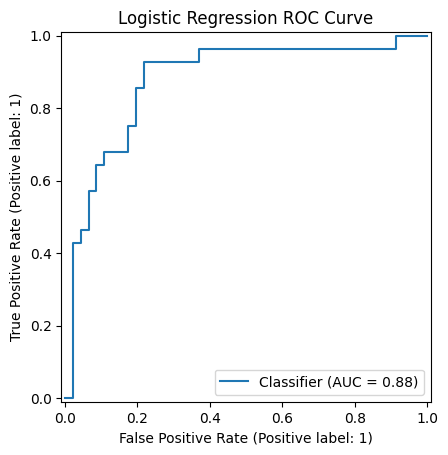


Random Forest RESULTS
              precision    recall  f1-score   support

           0       0.93      0.89      0.91        46
           1       0.83      0.89      0.86        28

    accuracy                           0.89        74
   macro avg       0.88      0.89      0.89        74
weighted avg       0.89      0.89      0.89        74

Accuracy: 0.8918918918918919
Precision: 0.8333333333333334
Recall: 0.8928571428571429
F1: 0.8620689655172413
ROC-AUC: 0.9041149068322981


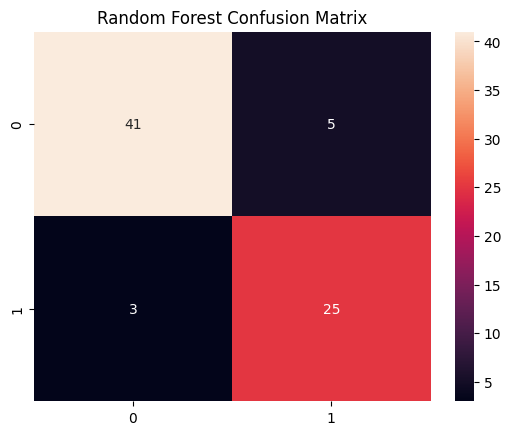

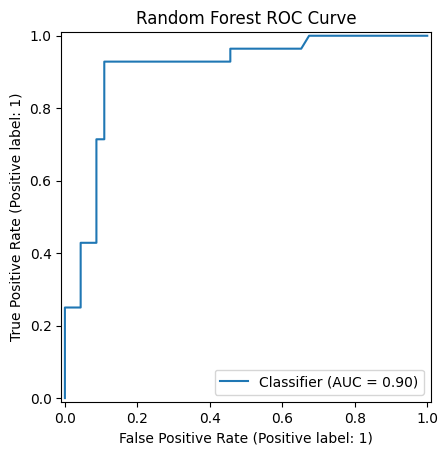

In [27]:
evaluate(log_model, "Logistic Regression")
evaluate(rf_model, "Random Forest")

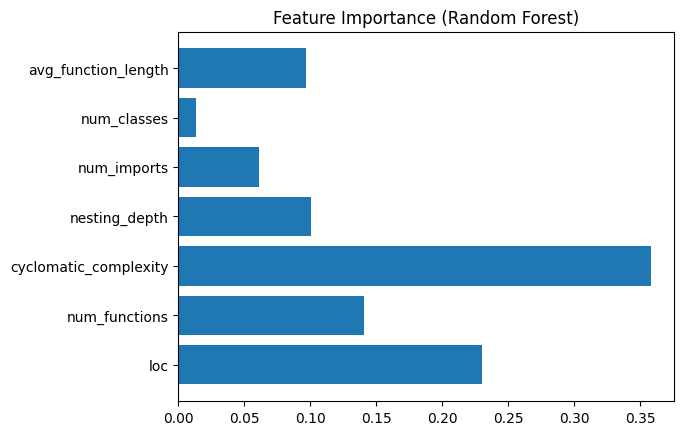

In [28]:
importances = rf_model.feature_importances_
plt.barh(FEATURES, importances)
plt.title("Feature Importance (Random Forest)")
plt.show()

In [29]:
joblib.dump({
    "model": rf_model,
    "scaler": scaler,
    "features": FEATURES
}, "random_forest_model.pkl")

['random_forest_model.pkl']

In [30]:
from google.colab import files
files.download("random_forest_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>